# RetailPulse

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import os
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.2f}'.format)

/Users/patilbhagyeshdinesh/Downloads/RetailPulse/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Forecast Preparation

In [3]:
# Load and reindex to a full daily calendar (fill missing days with 0)
raw = pd.read_csv('../data/processed/daily_sales.csv', parse_dates=['Date'])
raw = raw.sort_values('Date').set_index('Date')

full_idx = pd.date_range(raw.index.min(), raw.index.max(), freq='D')
sales = raw.reindex(full_idx, fill_value=0).rename_axis('Date').reset_index()
sales.columns = ['ds', 'y']

print(f'Date range : {sales.ds.min().date()} → {sales.ds.max().date()}')
print(f'Total days : {len(sales)}')
sales.tail()

Date range : 2009-12-01 → 2011-12-09
Total days : 739


,ds,y
734,2011-12-05,58081.09
735,2011-12-06,45989.66
736,2011-12-07,69230.60
737,2011-12-08,50395.96
738,2011-12-09,184347.66


In [4]:
# Train / test split — hold out last 30 days as test set
HORIZON = 30

train = sales.iloc[:-HORIZON].copy()
test  = sales.iloc[-HORIZON:].copy()

print(f'Train: {train.ds.min().date()} → {train.ds.max().date()}  ({len(train)} days)')
print(f'Test : {test.ds.min().date()}  → {test.ds.max().date()}   ({len(test)} days)')

Train: 2009-12-01 → 2011-11-09  (709 days)
Test : 2011-11-10  → 2011-12-09   (30 days)


## 2. Baseline Forecasting — Moving Average

In [5]:
# 30-day rolling mean on training data; last value carried forward as forecast
WINDOW = 30
ma_value = train['y'].rolling(WINDOW).mean().iloc[-1]
baseline_pred = np.full(HORIZON, ma_value)

print(f'Moving-average ({WINDOW}d) baseline value: £{ma_value:,.2f}')

Moving-average (30d) baseline value: £34,644.96


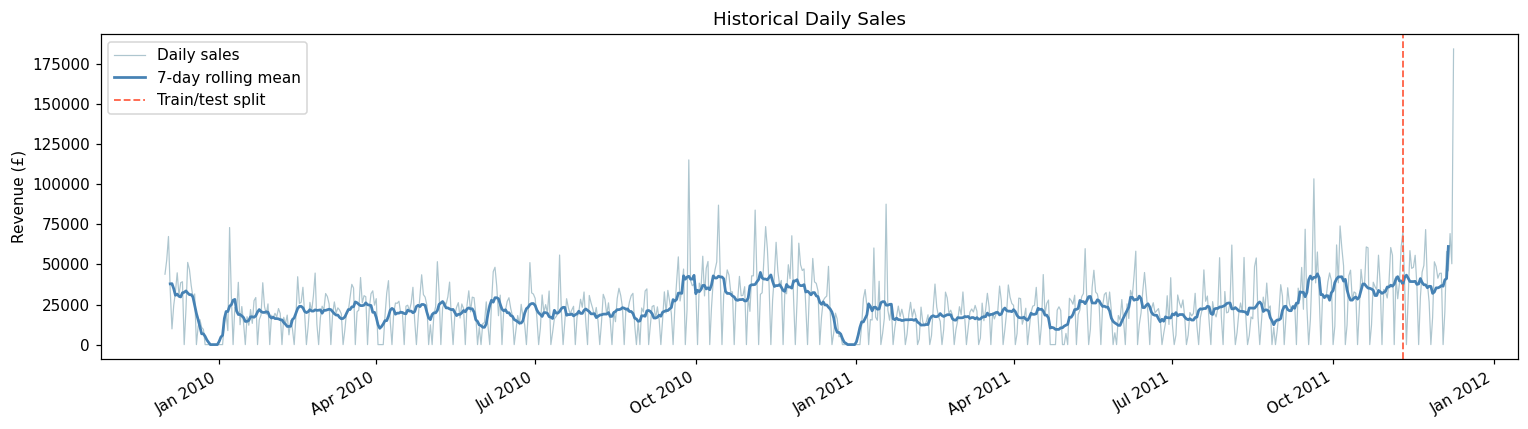

In [6]:
# Historical trend — weekly rolling mean for context
sales_plot = sales.set_index('ds')['y']
rolling_7  = sales_plot.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sales_plot.index, sales_plot.values, color='#aec6cf', lw=0.8, label='Daily sales')
ax.plot(rolling_7.index, rolling_7.values, color='steelblue', lw=1.8, label='7-day rolling mean')
ax.axvline(test.ds.min(), color='tomato', ls='--', lw=1.2, label='Train/test split')
ax.set_title('Historical Daily Sales')
ax.set_ylabel('Revenue (£)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3. Prophet Forecasting

In [7]:
# Train Prophet on the training set
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
)
model.fit(train)
print('Prophet model trained.')

20:37:27 - cmdstanpy - INFO - Chain [1] start processing
20:37:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained.


In [8]:
# Generate forecast for the test period + 30 extra days beyond the dataset
future = model.make_future_dataframe(periods=HORIZON + HORIZON, freq='D')
forecast = model.predict(future)

# Predictions aligned to the test window
prophet_test = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Next-30-days forecast (beyond the dataset)
last_date = sales['ds'].max()
next30 = forecast[forecast['ds'] > last_date].head(HORIZON)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print('Next 30 days predicted sales:')
print(next30.to_string(index=False))

Next 30 days predicted sales:
        ds      yhat  yhat_lower  yhat_upper
2011-12-10   9652.90    -3696.20    23363.50
2011-12-11  25579.37    11254.45    39246.83
2011-12-12  33188.90    19837.95    46144.75
2011-12-13  36731.16    22951.33    49398.38
2011-12-14  31154.28    17410.88    44587.35
2011-12-15  37024.10    23065.38    49227.15
2011-12-16  23324.16     9891.73    36795.80
2011-12-17  -4252.65   -16736.98     9823.54
2011-12-18  11483.68    -1972.26    24880.67
2011-12-19  19073.20     5657.84    32862.23
2011-12-20  22781.83     9016.42    36653.17
2011-12-21  17550.04     4449.01    31180.42
2011-12-22  23986.20    10793.65    37374.76
2011-12-23  11002.39    -2938.06    24239.34
2011-12-24 -15706.25   -28394.47    -2266.40
2011-12-25   1157.76   -12197.48    14690.28
2011-12-26  10007.18    -3421.41    23791.40
2011-12-27  15095.48     1185.89    28700.65
2011-12-28  11327.78    -3200.56    25428.08
2011-12-29  19329.01     6664.23    32566.44
2011-12-30   7916.12    -

## 4. Forecast Evaluation

In [9]:
y_true = test['y'].values

# --- Baseline metrics ---
mae_base  = mean_absolute_error(y_true, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_true, baseline_pred))
mape_base = np.mean(np.abs((y_true - baseline_pred) / np.where(y_true == 0, 1, y_true))) * 100

# --- Prophet metrics ---
y_prophet = prophet_test['yhat'].values
mae_prop  = mean_absolute_error(y_true, y_prophet)
rmse_prop = np.sqrt(mean_squared_error(y_true, y_prophet))
mape_prop = np.mean(np.abs((y_true - y_prophet) / np.where(y_true == 0, 1, y_true))) * 100

metrics = pd.DataFrame({
    'Model'  : ['Moving Average', 'Prophet'],
    'MAE'    : [mae_base,  mae_prop],
    'RMSE'   : [rmse_base, rmse_prop],
    'MAPE %' : [mape_base, mape_prop],
})
print(metrics.to_string(index=False))

         Model      MAE     RMSE    MAPE %
Moving Average 21990.24 34193.62 461962.97
       Prophet 14766.67 29792.24 232221.25


## 5. Forecast Visualisation

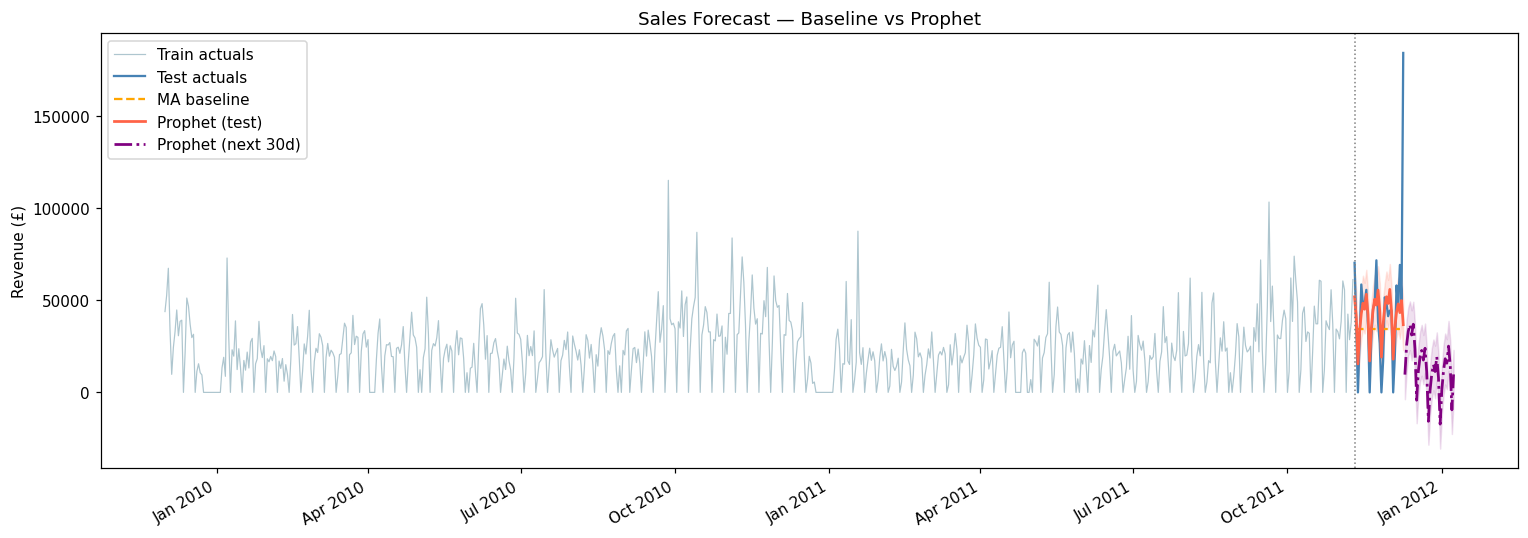

In [10]:
# --- Full forecast plot ---
fig, ax = plt.subplots(figsize=(14, 5))

# Historical actuals
ax.plot(train['ds'], train['y'], color='#aec6cf', lw=0.8, label='Train actuals')
ax.plot(test['ds'],  test['y'],  color='steelblue', lw=1.5, label='Test actuals')

# Baseline
ax.plot(test['ds'], baseline_pred, color='orange', ls='--', lw=1.5, label='MA baseline')

# Prophet on test window
ax.plot(prophet_test['ds'], prophet_test['yhat'], color='tomato', lw=1.8, label='Prophet (test)')
ax.fill_between(prophet_test['ds'],
                prophet_test['yhat_lower'], prophet_test['yhat_upper'],
                color='tomato', alpha=0.15)

# Next-30-days forecast
ax.plot(next30['ds'], next30['yhat'], color='purple', lw=1.8, ls='-.', label='Prophet (next 30d)')
ax.fill_between(next30['ds'],
                next30['yhat_lower'], next30['yhat_upper'],
                color='purple', alpha=0.12)

ax.axvline(test['ds'].min(), color='grey', ls=':', lw=1)
ax.set_title('Sales Forecast — Baseline vs Prophet')
ax.set_ylabel('Revenue (£)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

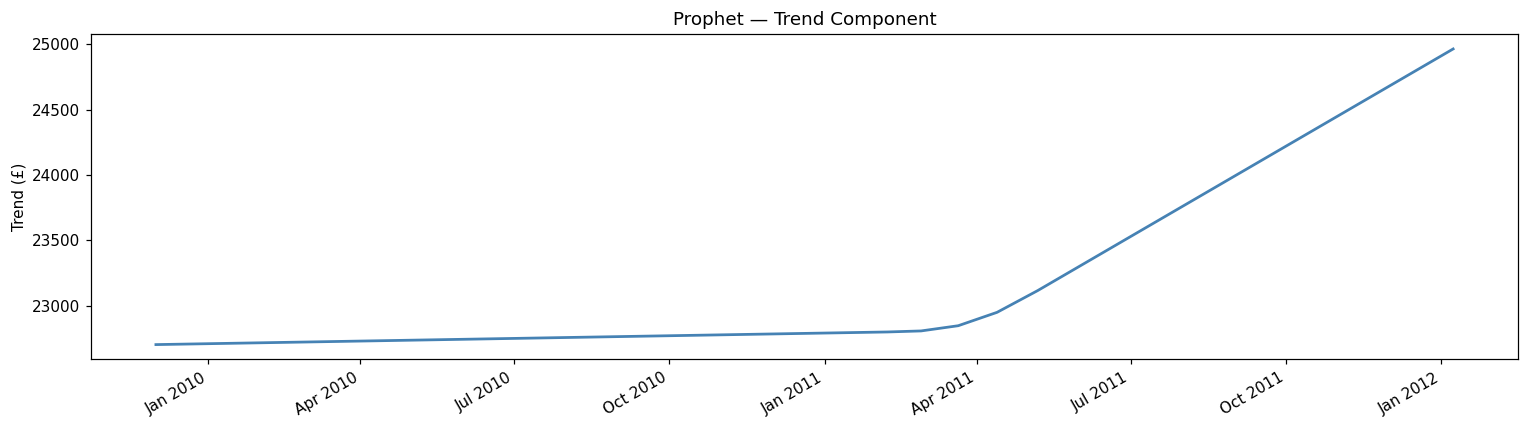

In [11]:
# --- Trend component ---
trend_df = forecast[['ds', 'trend']].set_index('ds')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(trend_df.index, trend_df['trend'], color='steelblue', lw=1.8)
ax.set_title('Prophet — Trend Component')
ax.set_ylabel('Trend (£)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

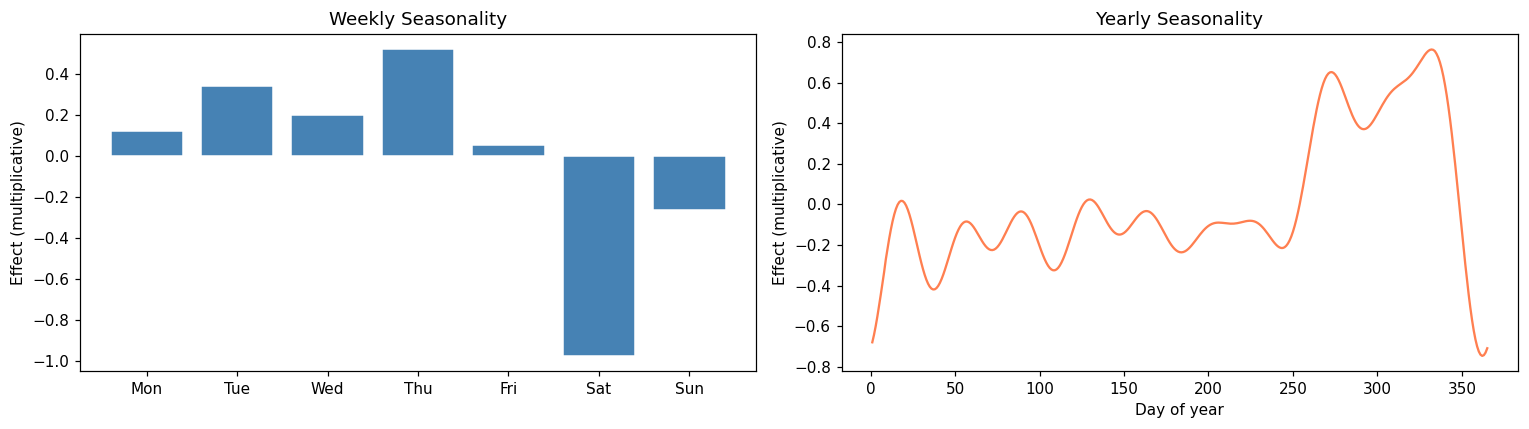

In [12]:
# --- Seasonality components ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Weekly seasonality — one representative week
week_df = forecast[['ds', 'weekly']].copy()
week_df['dow'] = week_df['ds'].dt.dayofweek
weekly_avg = week_df.groupby('dow')['weekly'].mean()
day_names  = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0].bar(day_names, weekly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Weekly Seasonality')
axes[0].set_ylabel('Effect (multiplicative)')

# Yearly seasonality — averaged by day-of-year
year_df = forecast[['ds', 'yearly']].copy()
year_df['doy'] = year_df['ds'].dt.dayofyear
yearly_avg = year_df.groupby('doy')['yearly'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, color='coral', lw=1.5)
axes[1].set_title('Yearly Seasonality')
axes[1].set_xlabel('Day of year')
axes[1].set_ylabel('Effect (multiplicative)')

plt.tight_layout()
plt.show()

## 6. Export

In [13]:
next30.to_csv('../data/processed/prophet_forecast_30d.csv', index=False)
print('Saved → data/processed/prophet_forecast_30d.csv')

Saved → data/processed/prophet_forecast_30d.csv


## 7. Save Model

In [14]:
import joblib
import os
import json
from prophet.serialize import model_to_json

os.makedirs('../models', exist_ok=True)

# Save using prophet's native json serializer
with open('../models/demand_forecasting_model.json', 'w') as fout:
    json.dump(model_to_json(model), fout)
    
print('Model saved to ../models/demand_forecasting_model.json')


Model saved to ../models/demand_forecasting_model.json


## 8. Data Preparation for Customer Segmentation

In [15]:
# Load the pre-scaled RFM data (already log-transformed + standardised)
rfm_scaled = pd.read_csv('../data/processed/rfm_scaled.csv')
rfm_raw    = pd.read_csv('../data/processed/rfm_dataset.csv')

print('Scaled shape:', rfm_scaled.shape)
rfm_scaled.head()

Scaled shape: (5878, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.00,0.60,1.25,3.21
1,12347.00,-0.95,0.80,1.22
2,12348.00,-0.60,0.30,0.57
3,12349.00,-0.87,0.07,1.14
4,12350.00,0.52,-1.06,-0.72


In [16]:
# Features used for clustering
features = ['Recency', 'Frequency', 'Monetary']
X = rfm_scaled[features].values
print('Feature matrix shape:', X.shape)

Feature matrix shape: (5878, 3)


## 9. Find Optimal Number of Clusters

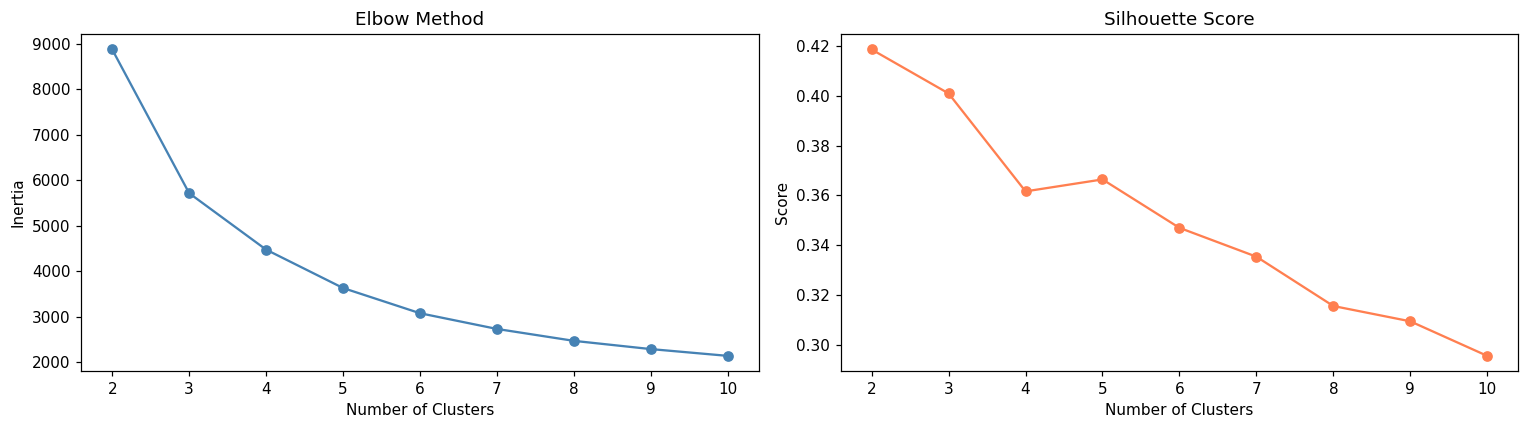

Best k by silhouette: 2  (score=0.419)


In [17]:
# Elbow method + silhouette scores
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'Best k by silhouette: {best_k}  (score={max(sil_scores):.3f})')

## 10. Train KMeans & Assign Cluster Labels

In [18]:
# We'll use 4 clusters — maps cleanly to the 4 business segments below
N_CLUSTERS = 4

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
rfm_raw['Cluster'] = km.fit_predict(X)

print('Cluster counts:')
print(rfm_raw['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    1494
1    1646
2     876
3    1862
Name: count, dtype: int64


## 11. Cluster Analysis

In [19]:
# Mean RFM per cluster — raw values for interpretability
cluster_summary = rfm_raw.groupby('Cluster')[features].mean().round(1)
cluster_summary['Count'] = rfm_raw.groupby('Cluster')['CustomerID'].count()
print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0         101.90       1.80    460.70   1494
1         491.10       1.70    521.30   1646
2          37.40      23.40  13656.70    876
3          98.90       5.90   2075.80   1862


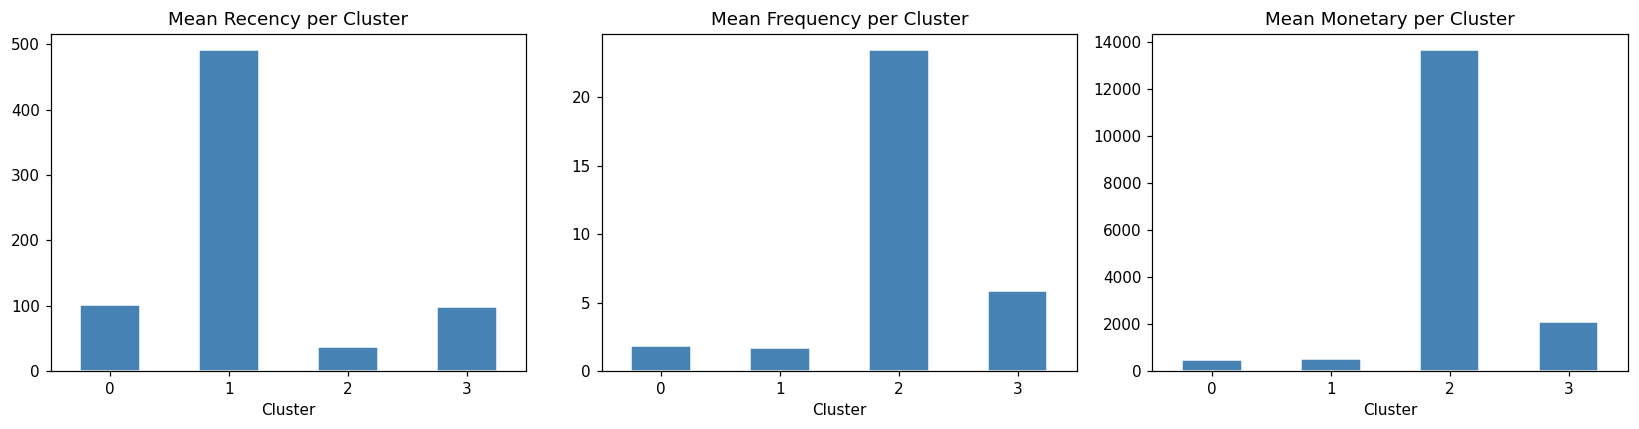

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, features):
    rfm_raw.groupby('Cluster')[col].mean().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Mean {col} per Cluster')
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 12. Business Segmentation

In [21]:
# Rank clusters by Monetary (desc) to assign business labels
monetary_rank = cluster_summary['Monetary'].rank(ascending=False).astype(int)
recency_rank  = cluster_summary['Recency'].rank(ascending=True).astype(int)   # lower recency = more recent
freq_rank     = cluster_summary['Frequency'].rank(ascending=False).astype(int)

# Combined score: lower is better
combined = monetary_rank + recency_rank + freq_rank
rank_order = combined.sort_values()

segment_labels = ['VIP', 'Loyal', 'At-Risk', 'Low-Value']
cluster_to_segment = {cluster: label for cluster, label in zip(rank_order.index, segment_labels)}

rfm_raw['Segment'] = rfm_raw['Cluster'].map(cluster_to_segment)

print('Segment mapping:', cluster_to_segment)
print()
print(rfm_raw.groupby('Segment')[features].mean().round(1))

Segment mapping: {2: 'VIP', 3: 'Loyal', 0: 'At-Risk', 1: 'Low-Value'}

           Recency  Frequency  Monetary
Segment                                
At-Risk     101.90       1.80    460.70
Low-Value   491.10       1.70    521.30
Loyal        98.90       5.90   2075.80
VIP          37.40      23.40  13656.70


## 13. Visualisations

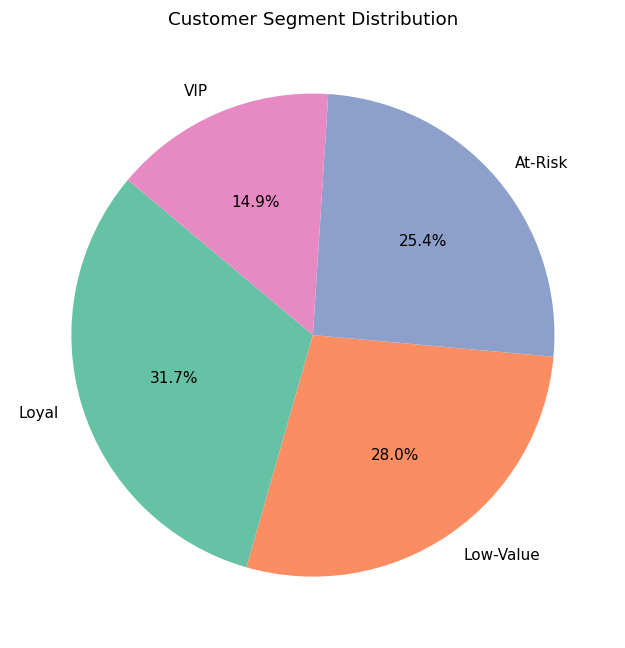

In [23]:
import seaborn as sns

# --- Cluster distribution (pie) ---
seg_counts = rfm_raw['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(seg_counts)), startangle=140)
ax.set_title('Customer Segment Distribution')
plt.tight_layout()
plt.show()

/var/folders/sh/gcjsrlxs6vg692fzs29_z0w00000gn/T/ipykernel_13004/290055986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm_raw, x='Segment', y=col, order=order,
/var/folders/sh/gcjsrlxs6vg692fzs29_z0w00000gn/T/ipykernel_13004/290055986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm_raw, x='Segment', y=col, order=order,
/var/folders/sh/gcjsrlxs6vg692fzs29_z0w00000gn/T/ipykernel_13004/290055986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm_raw, x='Segment', y=col, order=order,


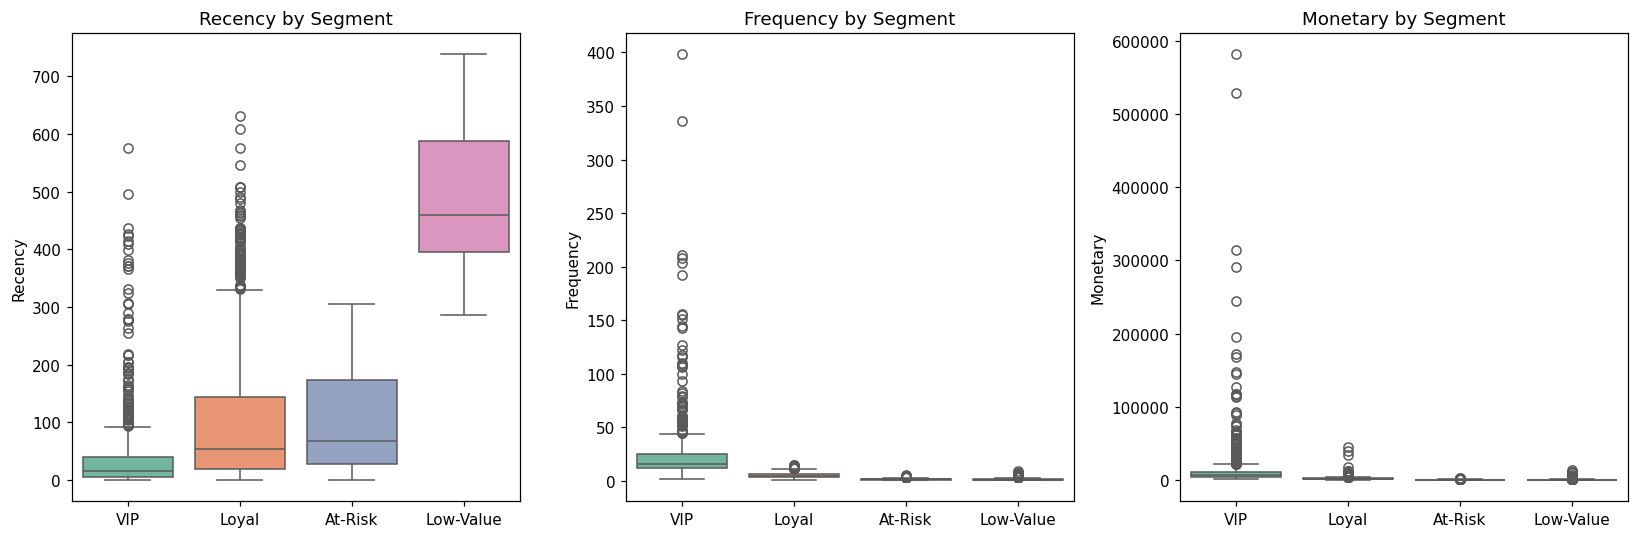

In [24]:
# --- RFM box-plots per segment ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = sns.color_palette('Set2', 4)
order   = ['VIP', 'Loyal', 'At-Risk', 'Low-Value']

for ax, col in zip(axes, features):
    sns.boxplot(data=rfm_raw, x='Segment', y=col, order=order,
                palette=palette, ax=ax)
    ax.set_title(f'{col} by Segment')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

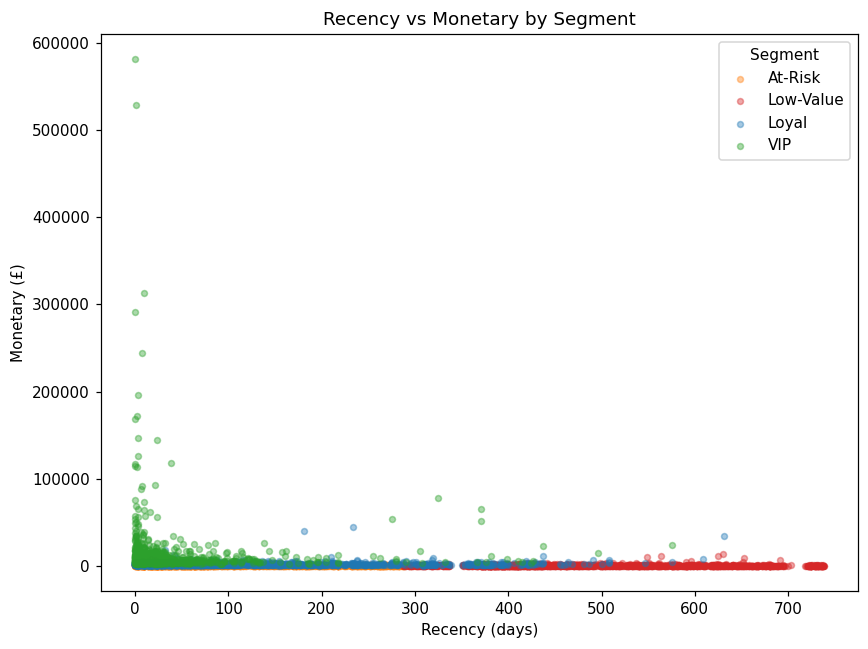

In [25]:
# --- Scatter: Recency vs Monetary, coloured by segment ---
palette_map = {'VIP': '#2ca02c', 'Loyal': '#1f77b4',
               'At-Risk': '#ff7f0e', 'Low-Value': '#d62728'}

fig, ax = plt.subplots(figsize=(8, 6))
for seg, grp in rfm_raw.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Monetary'],
               label=seg, alpha=0.4, s=15, color=palette_map[seg])

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (£)')
ax.set_title('Recency vs Monetary by Segment')
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

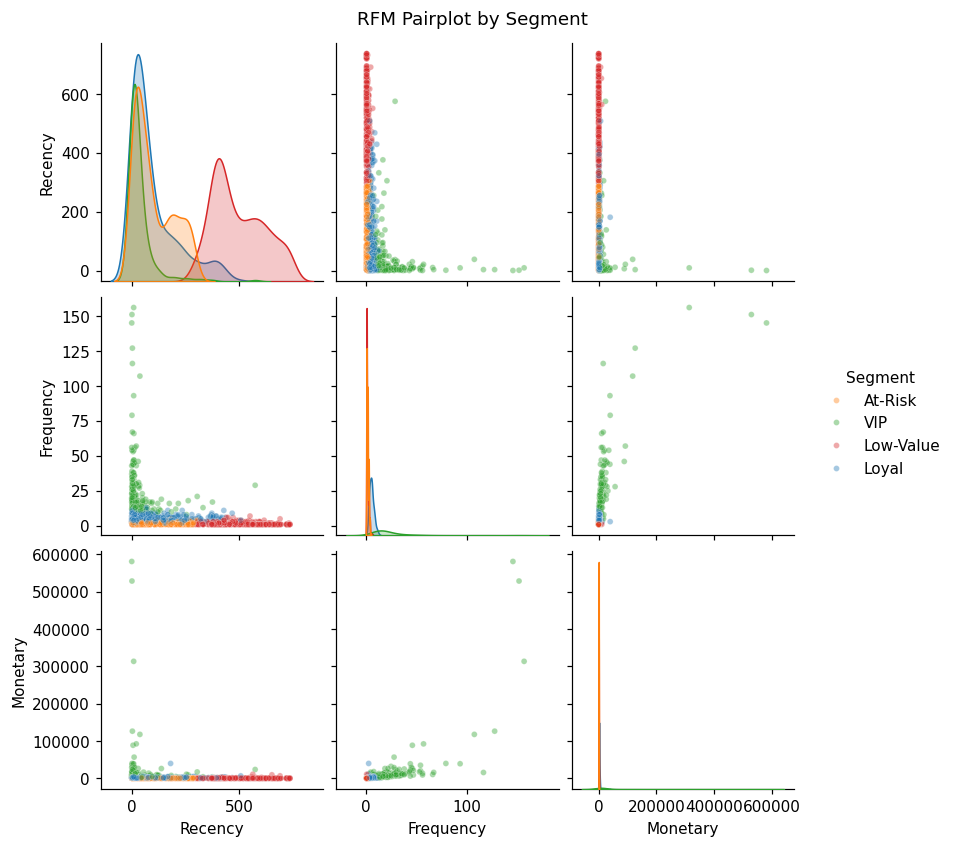

In [26]:
# --- Pairplot (sampled for speed) ---
sample = rfm_raw.sample(min(1500, len(rfm_raw)), random_state=42)
pp = sns.pairplot(sample[features + ['Segment']], hue='Segment',
                  palette=palette_map, plot_kws={'alpha': 0.4, 's': 15},
                  diag_kind='kde')
pp.fig.suptitle('RFM Pairplot by Segment', y=1.02)
plt.show()

## 14. Export

In [27]:
out = rfm_raw[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']]
out.to_csv('../data/processed/customer_segments.csv', index=False)
print('Saved → data/processed/customer_segments.csv')
out.head()

Saved → data/processed/customer_segments.csv


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.00,325,12,77556.46,2,VIP
1,12347.00,1,8,4921.53,3,Loyal
2,12348.00,74,5,2019.40,3,Loyal
3,12349.00,18,4,4428.69,3,Loyal
4,12350.00,309,1,334.40,1,Low-Value


## 15. Save Model

In [28]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(km, '../models/customer_segmentation_model.pkl')
print('Model saved to ../models/customer_segmentation_model.pkl')


Model saved to ../models/customer_segmentation_model.pkl


## 16. Dataset Preparation Customer Churn Prediction

In [29]:
# Load the dataset
df = pd.read_csv('../data/processed/customer_features.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5878, 8)


,Customer ID,TotalOrders,TotalItemsPurchased,TotalRevenue,AverageBasketSize,PurchaseFrequency,LastPurchaseGap,CustomerActivityStatus
0,12346.00,12,74285,77556.46,6190.42,0.90,325,Churned
1,12347.00,8,2967,4921.53,370.88,0.60,1,Active
2,12348.00,5,2714,2019.40,542.80,0.41,74,Active
3,12349.00,4,1624,4428.69,406.00,0.21,18,Active
4,12350.00,1,197,334.40,197.00,1.00,309,Churned


In [30]:
# 1. Define churn condition & Create churn labels
# CustomerActivityStatus is already defined, let's map it to binary 1 (Churned) and 0 (Active)
df['IsChurn'] = df['CustomerActivityStatus'].apply(lambda x: 1 if x == 'Churned' else 0)

print("Churn Distribution:")
print(df['IsChurn'].value_counts(normalize=True))

Churn Distribution:
IsChurn
1   0.51
0   0.49
Name: proportion, dtype: float64


In [31]:
# 2. Select churn-related features
# We drop 'LastPurchaseGap' and 'CustomerActivityStatus' to prevent target leakage
features = ['TotalOrders', 'TotalItemsPurchased', 'TotalRevenue', 'AverageBasketSize', 'PurchaseFrequency']
X = df[features]
y = df['IsChurn']

X.head()

,TotalOrders,TotalItemsPurchased,TotalRevenue,AverageBasketSize,PurchaseFrequency
0,12,74285,77556.46,6190.42,0.90
1,8,2967,4921.53,370.88,0.60
2,5,2714,2019.40,542.80,0.41
3,4,1624,4428.69,406.00,0.21
4,1,197,334.40,197.00,1.00


## 17. Model Preparation

In [32]:
# Split train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (4702, 5)
Test set shape: (1176, 5)


In [33]:
# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Handle class imbalance if needed
# Here the classes are almost perfectly balanced, but we include SMOTE for illustration
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Resampled Train set shape: {X_train_resampled.shape}")

Resampled Train set shape: (4776, 5)


## 18. Model Training

In [34]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

In [35]:
# Train Random Forest/XGBoost model
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

## 19. Model Evaluation

In [36]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc}

lr_metrics = evaluate_model(y_test, lr_preds, lr_probs, "Logistic Regression")
xgb_metrics = evaluate_model(y_test, xgb_preds, xgb_probs, "XGBoost")

--- Logistic Regression Performance ---
Accuracy:  0.7066
Precision: 0.6780
Recall:    0.8040
F1 Score:  0.7356
ROC-AUC:   0.7711

--- XGBoost Performance ---
Accuracy:  0.6888
Precision: 0.6808
Recall:    0.7286
F1 Score:  0.7039
ROC-AUC:   0.7681



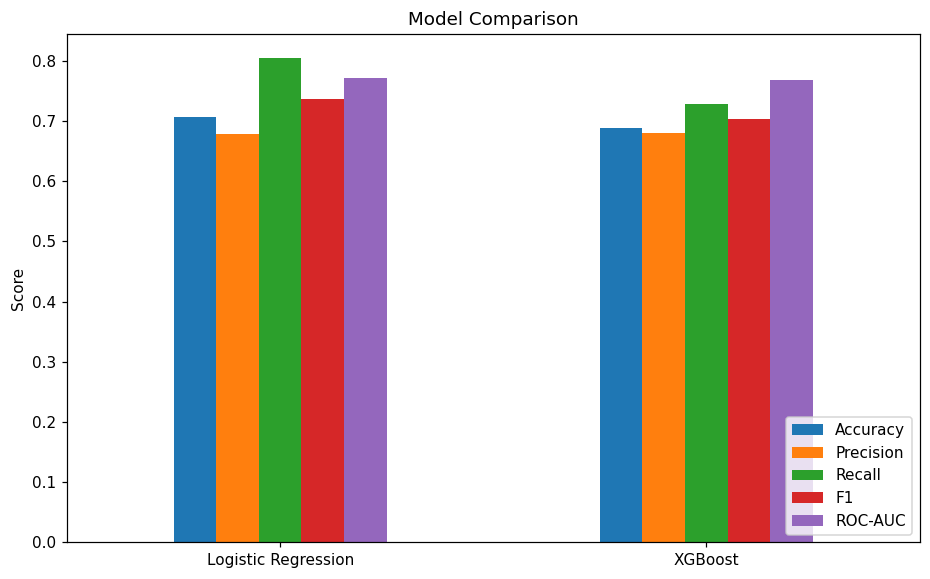

In [37]:
# Compare model performance
metrics_df = pd.DataFrame([lr_metrics, xgb_metrics], index=['Logistic Regression', 'XGBoost'])
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## 20. Feature Importance & Business Impact

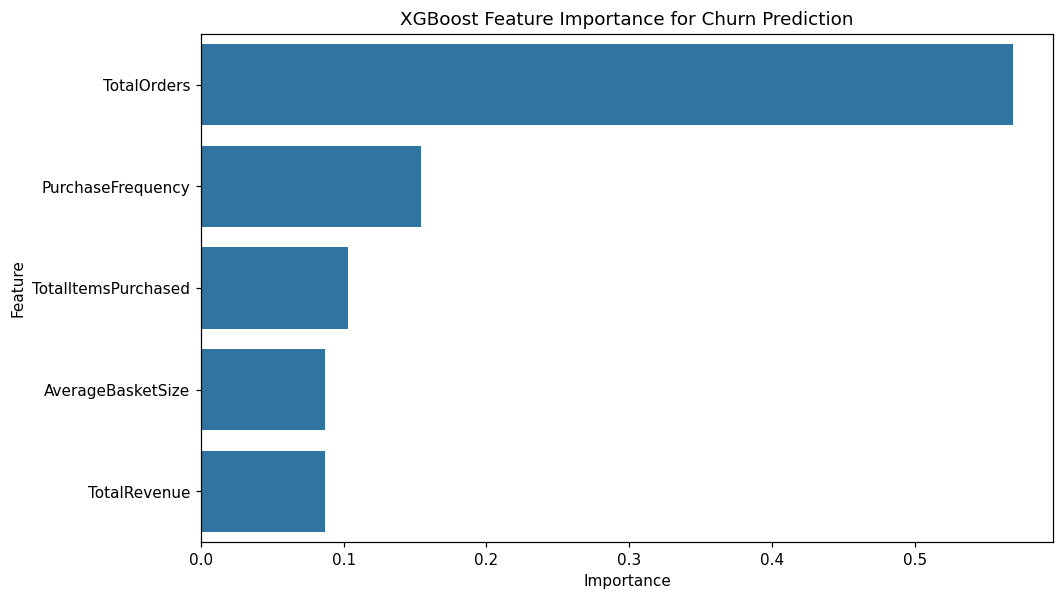

In [38]:
# Feature Importance using XGBoost
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance for Churn Prediction')
plt.show()

## 21. Save Model

In [39]:
# Ensure the models directory exists
os.makedirs("../models", exist_ok=True)

# Save the trained XGBoost model using joblib
model_path = "../models/xgb_churn_model.joblib"
joblib.dump(xgb_model, model_path)
print(f"Model successfully saved to {model_path}")

Model successfully saved to ../models/xgb_churn_model.joblib
